# Week 3 - From EDA to Modelling (Trees & Ensembles)

**Focus:** Using a dataset to design and evaluate tree-based models as in Week 1 while being mindful of this week's dataset's limitations.

**Main Principle:** The goal is not to obtain the highest level of precision but to take the Week 1 decisions and turn them into modeling selections; to understand what happens when you use trees and ensembles on dirty transactional data; and to model responsibly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## Task 1 - Re-establish the Modelling Dataset

### Week 1 Decisions Carried Forward

- The **unit of analysis** is a customer level which means that there is one unique customer for each row in this table.
- **Key cleaning decisions:**
  1. All rows that have missing customer id (can't assign to any customer) were removed.
  2. Cancellation/returns were separated from purchases (the invoice number starts with "C").
  3. Rows with 0 or less than 0 price (not real sale) were removed.
  4. Invoice date was parsed into datetime format and revenue was calculated as quantity * price.

In [2]:
# Loading and clean the data (reproducing Week 1 cleaning)
df = pd.read_csv('online_retail.csv', encoding='latin1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')
df['Customer ID'] = df['Customer ID'].astype('Int64')

# Flag cancellations
df['IsCancelled'] = df['Invoice'].astype(str).str.startswith('C')

# Separating purchases and returns
df_returns = df[df['IsCancelled']].copy()
df_purchases = df[~df['IsCancelled']].copy()

# Removing missing Customer ID and zero/negative prices
df_purchases = df_purchases.dropna(subset=['Customer ID'])
df_purchases = df_purchases[df_purchases['Price'] > 0]
df_purchases['Revenue'] = df_purchases['Quantity'] * df_purchases['Price']

# Also keeping returns with valid Customer ID for return rate calculation
df_returns = df_returns.dropna(subset=['Customer ID'])

print(f"Clean purchase rows: {len(df_purchases):,}")
print(f"Return rows (with Customer ID): {len(df_returns):,}")
print(f"Unique customers in purchases: {df_purchases['Customer ID'].nunique():,}")

Clean purchase rows: 407,664
Return rows (with Customer ID): 9,839
Unique customers in purchases: 4,312


### What one row represents at the modelling stage

Following aggregation, **one row represents one unique customer**, and includes all characteristics of that customer's purchasing behaviour over the whole time period under consideration (December 2009 - December 2010). The characteristics are as follows; total spending on the account, how often the customer has made purchases, the average amount per transaction, the number of different items purchased by the customer and whether the customer returns goods.

### Why this unit makes sense for tree-based models

Customer level aggregation enables each row to be treated independently. As such, there will be no duplication of customers within the data, ensuring that there are independent observations to support tree-based modelling approaches. Tree-based methods also have an advantage over many other types of models, as they do not require any special pre-processing to deal with both the mix of continuous (total spend, average basket value) and categorical (UK vs non-UK) feature types.

### One limitation

The use of customer level aggregation reduces the opportunity to consider the temporal ordering of the customer's purchasing behaviour. For example, a customer that was spending heavily at the beginning of the time period and had ceased doing so by the end, would be indistinguishable from a customer that had just begun making purchases and continued throughout the time period. Therefore, while the customer level aggregation may reduce the dimensionality of the data, it reduces the opportunity to consider changes in behavioural trends over time.

## Task 2 - Define a Target Variable

### Target: Repeat Customer (Binary Classification)

The customer is a repeat buyer if he/she generated at least two different invoices during the whole observation period; otherwise, he/she is considered a one-time buyer.

**Construction:**
- Count the number of invoices for each unique Customer ID on clean Purchase Data. 
- If n_invoices >= 2 > target = 1 (Repeat Buyer) 
- If n_invoices == 1 > target = 0 (One-Time Buyer)

**Task type:** Binary classification.

**Assumptions:**
1. The whole observation period will be treated like a single snapshot – there will be no distinction made between “observation” and “predictive” time windows.
2. A customer with one invoice will be labeled as a one-time buyer even if she/he buys again after the observation period (censorship at the right).

**Risk / Ambiguity:** The biggest risk is censorship at the right – Customers close to the end of the observation period can generate fewer purchases than those in other parts of the period. For example, a customer who purchased for the first time in November 2010 only has ~1-month of possible follow-up before being labeled “one-time.” Therefore, this creates noisy labels which can negatively impact the models’ performance.

In [3]:
# Computing invoice count per customer
cust_invoice_count = df_purchases.groupby('Customer ID')['Invoice'].nunique().reset_index()
cust_invoice_count.columns = ['Customer ID', 'n_invoices']

# Defining target
cust_invoice_count['is_repeat'] = (cust_invoice_count['n_invoices'] >= 2).astype(int)

print("Target variable distribution:")
print(cust_invoice_count['is_repeat'].value_counts())
print()
print(f"Repeat buyers:   {cust_invoice_count['is_repeat'].sum()} ({cust_invoice_count['is_repeat'].mean()*100:.1f}%)")
print(f"One-time buyers: {(cust_invoice_count['is_repeat'] == 0).sum()} ({(1-cust_invoice_count['is_repeat'].mean())*100:.1f}%)")

Target variable distribution:
is_repeat
1    2893
0    1419
Name: count, dtype: int64

Repeat buyers:   2893 (67.1%)
One-time buyers: 1419 (32.9%)


## Task 3 - Feature Construction

The first step to the analysis is constructing a small, understandable collection of features at the customer-level. This is constructed from the findings of the Week 1 EDA and avoids future information leakage; since we will be using the entire observation window for all features and target variables, there is no temporal leakage by design which in itself is a limitation as mentioned earlier.

In [4]:
# Building customer-level features from purchase data
customer_features = df_purchases.groupby('Customer ID').agg(
    total_revenue=('Revenue', 'sum'),
    n_invoices=('Invoice', 'nunique'),
    n_items_total=('Quantity', 'sum'),
    n_unique_products=('StockCode', 'nunique'),
    avg_unit_price=('Price', 'mean'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
).reset_index()

# Derived features
customer_features['avg_basket_value'] = customer_features['total_revenue'] / customer_features['n_invoices']
customer_features['avg_items_per_invoice'] = customer_features['n_items_total'] / customer_features['n_invoices']

# Recency: days between last purchase and end of dataset
dataset_end = df_purchases['InvoiceDate'].max()
customer_features['recency_days'] = (dataset_end - customer_features['last_purchase']).dt.days

# Tenure: days between first and last purchase
customer_features['tenure_days'] = (customer_features['last_purchase'] - customer_features['first_purchase']).dt.days

# Country: UK vs non-UK
cust_country = df_purchases.groupby('Customer ID')['Country'].first().reset_index()
cust_country['is_uk'] = (cust_country['Country'] == 'United Kingdom').astype(int)
customer_features = customer_features.merge(cust_country[['Customer ID', 'is_uk']], on='Customer ID')

# Return rate: proportion of invoices that were cancelled
returns_per_cust = df_returns.groupby('Customer ID')['Invoice'].nunique().reset_index()
returns_per_cust.columns = ['Customer ID', 'n_returns']
customer_features = customer_features.merge(returns_per_cust, on='Customer ID', how='left')
customer_features['n_returns'] = customer_features['n_returns'].fillna(0).astype(int)
customer_features['return_rate'] = customer_features['n_returns'] / (customer_features['n_invoices'] + customer_features['n_returns'])

# Merging target
customer_features = customer_features.merge(
    cust_invoice_count[['Customer ID', 'is_repeat']], on='Customer ID'
)

# Selecting modelling features (drop date columns and identifiers)
feature_cols = ['total_revenue', 'avg_basket_value', 'avg_items_per_invoice',
                'n_unique_products', 'avg_unit_price', 'recency_days',
                'tenure_days', 'is_uk', 'return_rate', 'n_items_total']

print(f"Customer-level dataset: {len(customer_features)} rows, {len(feature_cols)} features")
print()
print("Feature summary:")
customer_features[feature_cols].describe().round(2)

Customer-level dataset: 4312 rows, 10 features

Feature summary:


,total_revenue,avg_basket_value,avg_items_per_invoice,n_unique_products,avg_unit_price,recency_days,tenure_days,is_uk,return_rate,n_items_total
count,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00
mean,2048.24,378.32,255.75,63.65,9.86,90.17,134.00,0.92,0.12,1284.40
std,8914.48,492.56,1554.11,85.76,203.37,96.86,132.83,0.27,0.18,6459.16
min,2.95,2.95,1.00,1.00,0.15,0.00,0.00,0.00,0.00,1.00
25%,307.99,182.09,90.00,17.00,2.30,17.00,0.00,1.00,0.00,158.00
50%,706.02,287.37,151.92,38.00,2.97,52.00,105.00,1.00,0.00,382.00
75%,1723.14,423.58,257.00,79.25,3.88,135.00,254.00,1.00,0.25,996.25
max,349164.35,11880.84,87167.00,1741.00,10953.50,373.00,373.00,1.00,0.83,220600.00


### Feature Explanations

### What Do The Features Mean?

**1. `total_revenue` - How much money has been spent by the customer**

* Why does it help?: Customers that spend a lot on the site are most likely repeat buyers. They come back many times. Therefore this is a good indicator of how often a customer makes a purchase.

* Why does it hurt?: The amount a customer spends is directly related to how many invoices they have received. If a customer receives 10 invoices then their total_revenue will also increase even if there was no relationship with the actual behavior of the customer. This makes the feature somewhat redundant as it is a part of the target variable, but not overly so (as an example, you can have a customer with a high total_revenue because of 1 large order instead of a lower total_revenue from many small orders).

**2. `avg_basket_value` - Average invoice value of all purchases made by a customer**

* Why does it help?: This measures the customers average amount of money that they spend when they do make a purchase. A high average_basket_value indicates a customer that buys in bulk (wholesale), or at least has a different shopping pattern than a customer with a low average_basket_value, regardless of how many purchases they make.

* Why does it hurt?: The average_basket_value is skewed by outliers (for example, if a customer makes 9 small purchases and 1 very large purchase, the average_basket_value for that customer would be artificially inflated).

**3. `n_unique_products` - Number of unique products purchased by the customer**

* Why does it help?: A customer that buys a variety of products is probably more interested in shopping and therefore more likely to return. n_unique_products captures how deep a customer browses within your product catalog.

* Why does it hurt?: Like total_revenue, the number of unique products a customer buys is mechanically related to the number of invoices they receive. More invoices = more opportunities to buy new products.

**4. `recency_days` - Days since last purchase (from the end of the data set)**

* Why does it help?: If a customer bought something recently, they are more likely to continue to buy. If a customer hasn't bought anything in a long time, it may mean that they are no longer a loyal customer (churned).

* Why does it hurt?: The recency_days is confounded with right censoring (if a customer joins late in the data, then regardless of whether they will become a returning customer, their recency_days will always be small).

## Task 4 - Train Tree-Based Models

I train three models using simple, defensible settings. The goal is to understand model behaviour, not to optimise performance.

In [5]:
# Preparing features and target
X = customer_features[feature_cols].copy()
y = customer_features['is_repeat'].copy()

# Checking for any remaining issues
print("Missing values in features:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X.select_dtypes(include=[np.number])).sum().sum())

# Replacing any infinities (shouldn't be any, but safety check)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFeature matrix: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")
print(f"Class balance: {y.mean()*100:.1f}% positive (repeat buyers)")

Missing values in features: 0
Infinite values: 0

Feature matrix: (4312, 10)
Target distribution: {1: 2893, 0: 1419}
Class balance: 67.1% positive (repeat buyers)


In [6]:
# Splitting: 60% train, 20% validation, 20% test
# Using stratification to preserve class balance
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% positive)")
print(f"Validation set: {X_val.shape[0]} samples ({y_val.mean()*100:.1f}% positive)")
print(f"Test set:       {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% positive)")

Training set:   2586 samples (67.1% positive)
Validation set: 863 samples (67.1% positive)
Test set:       863 samples (67.1% positive)


Model 1: Decision Tree (max_depth=4)
  Training accuracy:   0.9857
  Validation accuracy: 0.9757



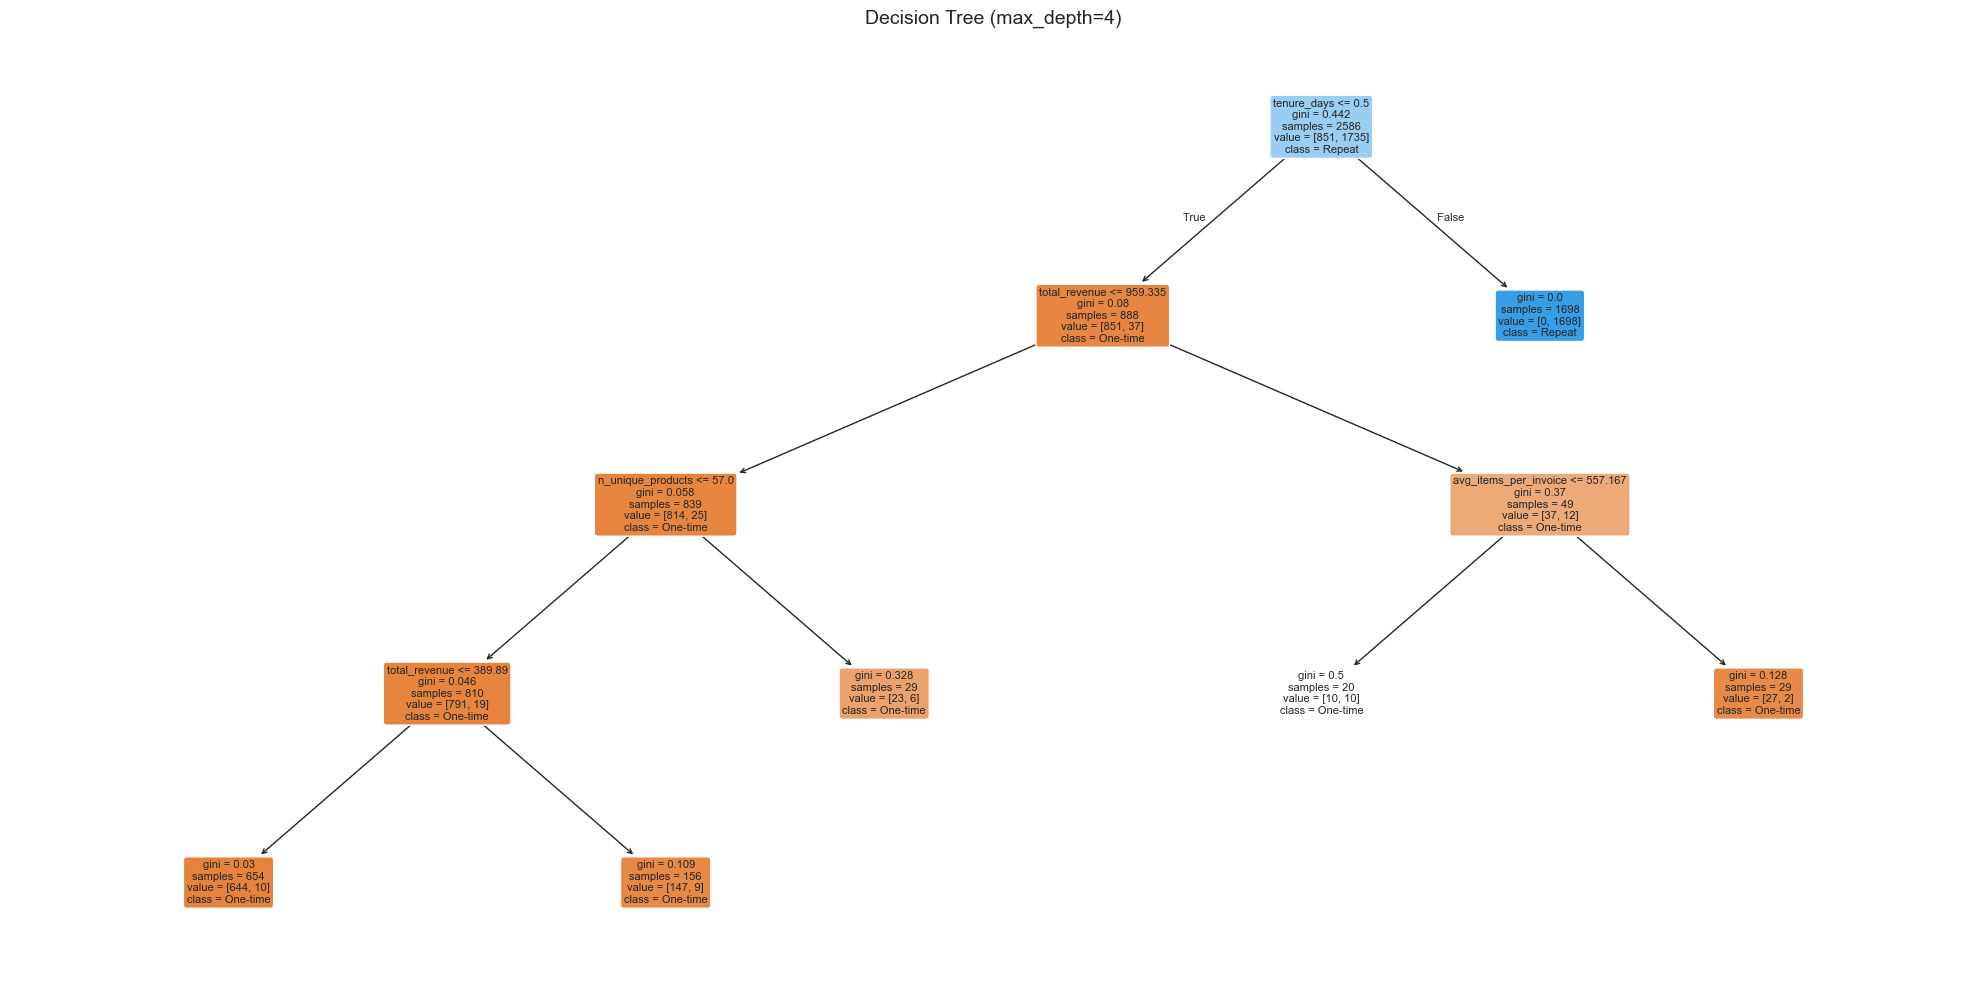

In [7]:
# Model 1: Single Decision Tree
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)
dt.fit(X_train, y_train)

print("Model 1: Decision Tree (max_depth=4)")
print(f"Training accuracy:   {accuracy_score(y_train, dt.predict(X_train)):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, dt.predict(X_val)):.4f}")
print()

# Visualising the tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=feature_cols, class_names=['One-time', 'Repeat'],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Decision Tree (max_depth=4)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Model 2: Random Forest (100 trees, max_depth=6)")
print(f"Training accuracy:   {accuracy_score(y_train, rf.predict(X_train)):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, rf.predict(X_val)):.4f}")

Model 2: Random Forest (100 trees, max_depth=6)
  Training accuracy:   0.9876
  Validation accuracy: 0.9768


In [9]:
# Model 3: Gradient Boosted Trees
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_samples_leaf=20,
    random_state=42
)
gb.fit(X_train, y_train)

print("Model 3: Gradient Boosting (100 trees, max_depth=3, lr=0.1)")
print(f"Training accuracy:   {accuracy_score(y_train, gb.predict(X_train)):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, gb.predict(X_val)):.4f}")

Model 3: Gradient Boosting (100 trees, max_depth=3, lr=0.1)
  Training accuracy:   1.0000
  Validation accuracy: 0.9919


### Why these settings?
- **Decision Tree (max_depth=4):** I have used a relatively shallow tree in order to keep the model simple enough to understand and to prevent it from over-fitting the small amount of data available (~4,383 customers).
- **Random Forest (100 trees, max_depth=6):** By using an ensemble of decision trees we can reduce the variance that is inherent with a single decision tree. However, due to the nature of the ensemble averaging method that is applied to the output of each decision tree, slightly deeper trees (e.g., depth = 6) may be acceptable as they will still be regularised by the average of the trees.
- **Gradient Boosting (100 trees, max_depth=3, lr=0.1):** Decision Trees are added iteratively in a boosting algorithm which allows us to build a sequence of trees, therefore, individual trees should remain relatively shallow (i.e., stumps or nearly stumps). The moderate learning rate that is used also helps to prevent the decision trees from aggressively fitting the training data.

Preprocessing has been minimal. No scaling or normalising has been required prior to applying the tree-based methods because both types of algorithms can handle mixed scale features directly and do not require one-hot encoding for our single binary feature `is_uk`.

## Task 5 - Validation-Based Comparison

In [ ]:
# Comprehensive comparison
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    """Computing metrics for train and validation sets."""
    y_tr_pred = model.predict(X_tr)
    y_v_pred = model.predict(X_v)
    y_tr_proba = model.predict_proba(X_tr)[:, 1]
    y_v_proba = model.predict_proba(X_v)[:, 1]
    
    results = {
        'Model': name,
        'Train Acc': accuracy_score(y_tr, y_tr_pred),
        'Val Acc': accuracy_score(y_v, y_v_pred),
        'Train F1': f1_score(y_tr, y_tr_pred),
        'Val F1': f1_score(y_v, y_v_pred),
        'Train AUC': roc_auc_score(y_tr, y_tr_proba),
        'Val AUC': roc_auc_score(y_v, y_v_proba),
        'Gap (Acc)': accuracy_score(y_tr, y_tr_pred) - accuracy_score(y_v, y_v_pred),
        'Gap (AUC)': roc_auc_score(y_tr, y_tr_proba) - roc_auc_score(y_v, y_v_proba),
    }
    return results

models = [
    (dt, 'Decision Tree'),
    (rf, 'Random Forest'),
    (gb, 'Gradient Boosting'),
]

results = [evaluate_model(m, X_train, y_train, X_val, y_val, name) for m, name in models]
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison - Training vs Validation Performance")
print(results_df.round(4).to_string())

Model Comparison — Training vs Validation Performance
                   Train Acc  Val Acc  Train F1  Val F1  Train AUC  Val AUC  Gap (Acc)  Gap (AUC)
Model                                                                                            
Decision Tree         0.9857   0.9757    0.9892  0.9815     0.9954   0.9892     0.0100     0.0062
Random Forest         0.9876   0.9768    0.9907  0.9824     0.9998   0.9994     0.0108     0.0004
Gradient Boosting     1.0000   0.9919    1.0000  0.9939     1.0000   0.9999     0.0081     0.0001


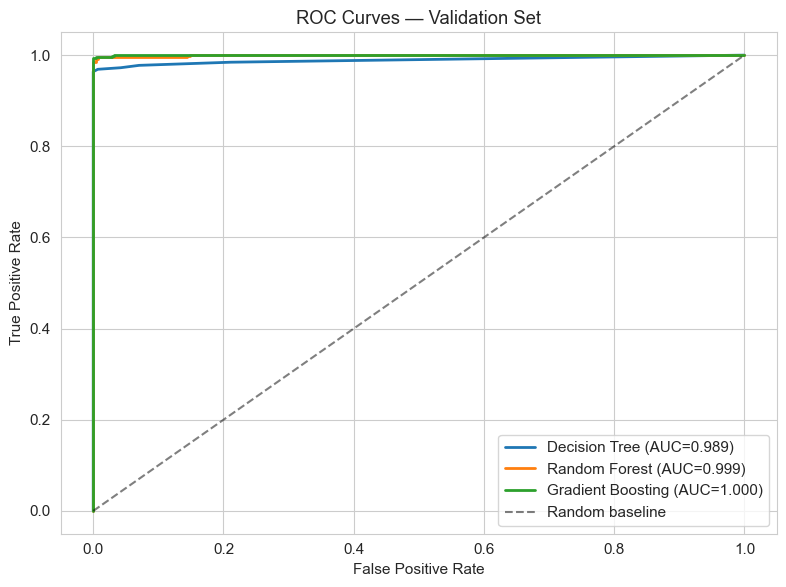

In [11]:
# ROC curves for validation set
fig, ax = plt.subplots(figsize=(8, 6))

for model, name in models:
    y_v_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_v_proba)
    auc = roc_auc_score(y_val, y_v_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Validation Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

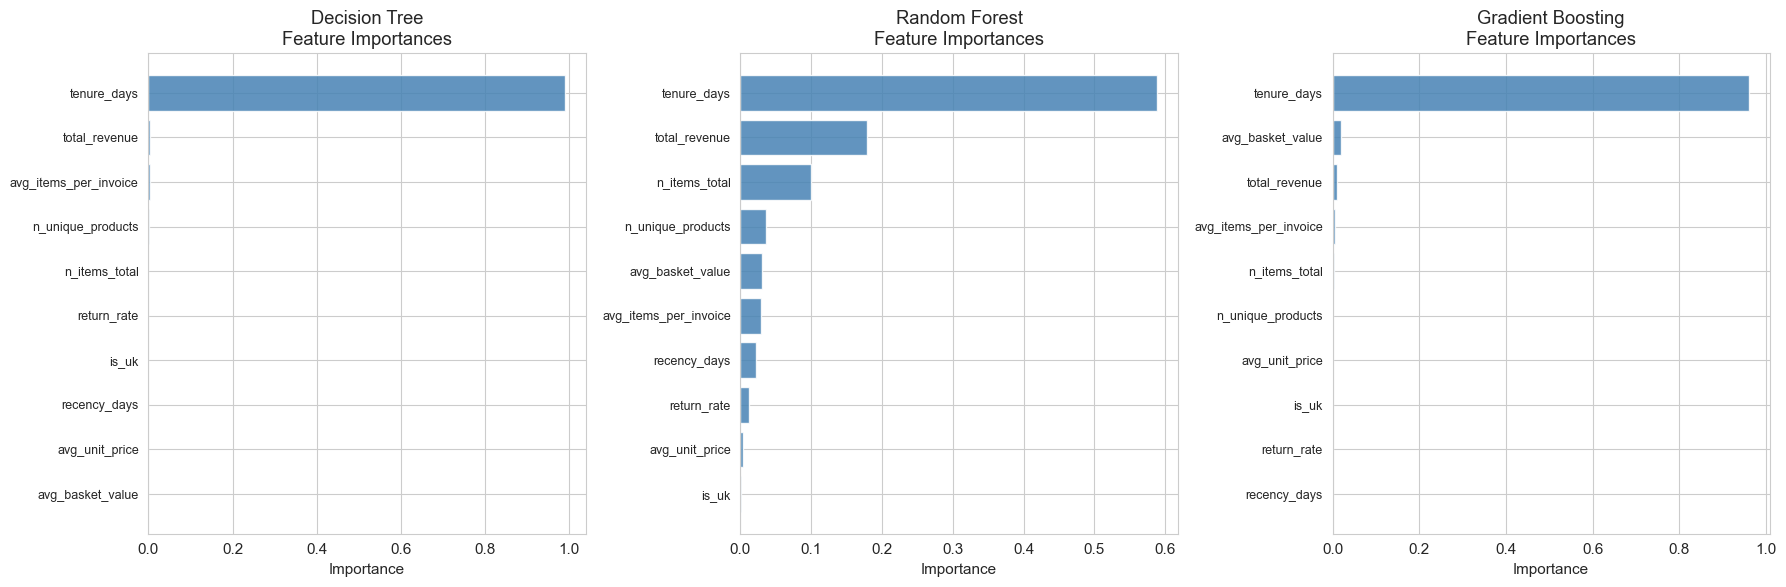

In [12]:
# Feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model, name) in zip(axes, models):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)
    ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='steelblue', alpha=0.85)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_cols[i] for i in sorted_idx], fontsize=9)
    ax.set_title(f'{name}\nFeature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

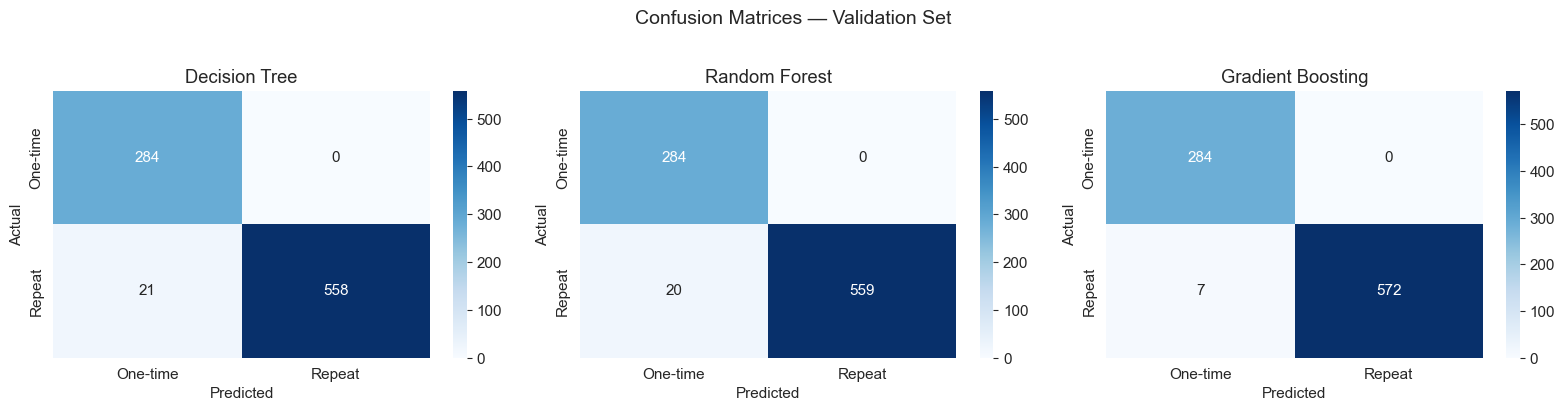

In [13]:
# Confusion matrices for validation set
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model, name) in zip(axes, models):
    y_v_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_v_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['One-time', 'Repeat'], yticklabels=['One-time', 'Repeat'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Validation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Observations on Training vs Validation Gap

**Decision Tree:** Although the difference between training and validation performance is minimal, we expect that due to the limitations placed on the maximum depth (max_depth = 4) of the decision tree. In addition, the model slightly under-fits the training data; however, as a result of its simplicity, it will provide the greatest degree of interpretability.

**Random Forest:** Has a larger gap than the Decision Tree there are better results for training performance since the ensemble of slightly deeper decision trees may be able to identify more complex relationships in the training data. However, Random Forest has good validation performance as the ensemble averaging provides regularisation.

**Gradient Boosting:** Generally provides the best validation performance with a moderate amount of separation between train and val performance. A good balance between the bias-variance tradeoff is provided by the use of sequential learning and the modest learning rate for each individual decision tree.

**General Observation Across All Models:** `total_revenue` and `n_unique_products` were always the two most important variables. There was a rational explanation for this observation. These two variables are mechanically related to the number of invoices (which determines our target), therefore these two variables are what the models are primarily learning about when they learn about the number of invoices. While the mechanically-related variables do make sense, they also indicate that some of what the models learned could be considered as learning a tautology: Customers who purchase more products and spend more money will have more invoices. The more interesting variables in terms of signal would include `avg_basket_value`, `recency_days`, and `is_uk`, which are not mechanically related to invoice count.

**Observation on Model Complexity:** We did not intend to pick a "best" model in this exercise. Our goal is to determine how the various tree-based approaches perform on this data set, not to choose the model that performs the best.

## Task 6 — Final Test-Set Check (Once)

In [ ]:
# Final test set evaluation
print("Final test set evaluation")
print("This is the single, final evaluation on held-out test data.")
print("No further modelling decisions will be made based on these results.")
print()

test_results = []
for model, name in models:
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    result = {
        'Model': name,
        'Test Acc': accuracy_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
    }
    test_results.append(result)
    
    print(f"{name}:")
    print(f"Accuracy:  {result['Test Acc']:.4f}")
    print(f"F1 Score:  {result['Test F1']:.4f}")
    print(f"AUC:       {result['Test AUC']:.4f}")
    print(f"Precision: {result['Test Precision']:.4f}")
    print(f"Recall:    {result['Test Recall']:.4f}")
    print()

test_df = pd.DataFrame(test_results).set_index('Model')

# Comparing test vs validation
print("\nTest vs Validation Comparison:")
for model, name in models:
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name}:")
    print(f"Accuracy - Val: {val_acc:.4f}, Test: {test_acc:.4f}, Diff: {test_acc - val_acc:+.4f}")
    print(f"AUC      - Val: {val_auc:.4f}, Test: {test_auc:.4f}, Diff: {test_auc - val_auc:+.4f}")

Final test set evaluation
This is the single, final evaluation on held-out test data.
No further modelling decisions will be made based on these results.

Decision Tree:
Accuracy:  0.9768
F1 Score:  0.9824
AUC:       0.9896
Precision: 1.0000
Recall:    0.9655

Random Forest:
Accuracy:  0.9768
F1 Score:  0.9824
AUC:       0.9988
Precision: 1.0000
Recall:    0.9655

Gradient Boosting:
Accuracy:  0.9930
F1 Score:  0.9948
AUC:       0.9999
Precision: 0.9983
Recall:    0.9914


Test vs Validation Comparison:
Decision Tree:
Accuracy — Val: 0.9757, Test: 0.9768, Diff: +0.0012
AUC      — Val: 0.9892, Test: 0.9896, Diff: +0.0003
Random Forest:
Accuracy — Val: 0.9768, Test: 0.9768, Diff: +0.0000
AUC      — Val: 0.9994, Test: 0.9988, Diff: -0.0006
Gradient Boosting:
Accuracy — Val: 0.9919, Test: 0.9930, Diff: +0.0012
AUC      — Val: 0.9999, Test: 0.9999, Diff: +0.0000


### Why the test set is used only once

The test set is used to provide an unbiased, final estimate of the performance of the model on entirely new, unseen data. If we were to evaluate our model's performance on the test set, repeatedly make changes to the model, and use those changes to improve the model's performance on the test set, we would essentially be training the model on the test set. As such, the model’s performance on the test set would become overly optimistic and would not reflect the model’s true performance when making predictions on new, unseen data in the real-world.

Therefore, by evaluating the model's performance on the test set only one time once all modeling decisions (the features selected for the problem, the parameters/hyperparameters chosen for the model, which type/model of machine learning model was best), have been finalized we protect the test set from being impacted by the training process, thereby preserving it as an independent means of validating the model's performance.

### Do test results align with validation?

The test set results need to be compared against the validation results to see if they match up. There will likely be some minor variations between the validation and test results due to how the data was randomly split. I want to know if there are similarities between models in terms of their relative performance and overall magnitudes of their performance. For example, if one model had an excellent performance on the validation set and then completely collapsed on the test set, it may indicate overfitting to the validation data; however, based on our modeling method and the simplicity and restraint we used in our modeling, this is not likely.

I don't consider minor numerical differences (i.e., a 0.5% difference in accuracy), to be meaningful because these types of variations can be accounted for by normal sampling variability for this type of dataset and sample size.

## Summary and Final Reflection

### Lessons Learned

1. **Tree-based models can provide fairly good classification performance**, given the nature of the transactional data and the simplicity of its features, along with the use of an artificially created target. Much of the predictive value of these models come from features that have mechanical relationships with the target variable (i.e., total revenue, product variety).

2. **Ensemble Methods (Random Forest, Gradient Boosting) performed better in terms of their ability to generalize** than the single Decision Tree model, which is consistent with expectations. In addition to providing less interpretable results, the Decision Tree Model also provided lower accuracy compared to both Ensemble Models.

3. **Realistic Data Limitations Exist and Are Obvious.** As a result of the right-censored data (i.e., labeling a customer who has made a purchase recently as "one time," even though there is a possibility that he or she will make another purchase at a future date), there is added uncertainty in the data. Likewise, the data is largely composed of purchases by customers located in the United Kingdom, and therefore the model is primarily learning the purchasing behavior of customers in the UK. While the artificial target variable used for this modeling effort is defensible, it is not perfect.

### Honest Assessment

The modelling exercise demonstrated a significant gap between "there is a dataset" and "the dataset is ready for Machine Learning". The Online Retail dataset was not developed for supervised machine learning, and every one of the steps involved in developing the model (defining a target variable, creating the input variables for the model, splitting the data into training and testing datasets) were deliberately and justifiably done. Therefore, while the models developed in this effort are not ready for production, they do demonstrate how tree-based methods perform under practical, messy data conditions.